# **U-Net: Implementation and Analysis**

---

## **Learning Objectives**

By the end of this tutorial, students will be able to:

1. **Understand** the U-Net architecture and its significance in biomedical image segmentation
2. **Implement** the U-Net model from scratch using PyTorch
3. **Apply** data preprocessing techniques for image segmentation tasks
4. **Train** deep learning models with appropriate loss functions and optimization strategies
5. **Evaluate** segmentation performance using metrics like the Dice coefficient
6. **Analyze** model performance on leaf disease segmentation as a case study

---

## **Prerequisites**

- Familiarity with PyTorch tensor operations and neural network modules
- Understanding of convolutional neural networks and their applications
- Knowledge of image processing fundamentals
- Basic understanding of medical image analysis concepts

---

### **Reference**
**Paper:** U-Net: Convolutional Networks for Biomedical Image Segmentation  
**Authors:** Olaf Ronneberger, Philipp Fischer, Thomas Brox  
**Publication:** International Conference on Medical Image Computing and Computer-Assisted Intervention (MICCAI), 2015  
**Paper Link:** https://arxiv.org/pdf/1505.04597.pdf

## **1. Overview and Theoretical Framework**

### **1.1 Introduction to U-Net Architecture**

The U-Net architecture represents a significant advancement in biomedical image segmentation. Originally developed for medical image segmentation tasks, it has become a foundational architecture for various computer vision applications. The architecture is characterized by:

1. **Encoder-Decoder Structure**: U-Net follows a symmetric encoder-decoder architecture, where the encoder extracts features through downsampling, and the decoder reconstructs the segmentation map through upsampling.

2. **Skip Connections**: One of U-Net's key innovations is the use of skip connections between corresponding encoder and decoder layers, allowing the network to retain spatial information lost during downsampling.

3. **Contextual Information**: The architecture effectively combines contextual information (from the contracting path) with precise localization (from the expanding path), making it particularly effective for segmentation tasks.

### **1.2 Applications in Biomedical Imaging**

U-Net has proven exceptionally effective for biomedical image segmentation due to its ability to:

- Perform accurate segmentation with limited training data through extensive data augmentation
- Capture fine boundaries between structures of interest
- Generate precise pixel-level classifications for complex anatomical structures

This tutorial implements U-Net for plant disease segmentation, demonstrating its versatility beyond medical imaging to other domains requiring precise segmentation.

In [1]:
# Install kagglehub to access the dataset repository
!pip install kagglehub gdown

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



In [2]:
import kagglehub

In [3]:
path = kagglehub.dataset_download("fakhrealam9537/leaf-disease-segmentation-dataset")

print("Path to dataset files:", path)

100%|██████████| 503M/503M [00:51<00:00, 10.2MB/s] 

Extracting files...


Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\fakhrealam9537\leaf-disease-segmentation-dataset\versions\4


In [4]:
# Define path constants for dataset organization
# Using a class allows for better code organization and easier path management
class ROOTDIR:
    # Path to the directory containing training images
    train = f"{path}/data/data/images"
    # Path to the directory containing corresponding segmentation masks
    train_mask = f"{path}/data/data/masks"

## **2. Environment Setup and Dependencies**

### **2.1 Library Imports**

The implementation utilizes several key Python libraries:

- **NumPy & Pandas**: For efficient numerical operations and data manipulation
- **PyTorch**: Deep learning framework for model implementation
- **OpenCV & PIL**: Image processing libraries for data preparation
- **Albumentations**: For image augmentation techniques
- **Matplotlib**: For visualization of images and model performance

In [ ]:
# install image processing libraries
%pip install cv2 matplotlib






Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2


In [10]:
# System and file handling libraries
import os
import zipfile

# Data manipulation and numerical operations
import numpy as np
import pandas as pd

# Image processing libraries
import cv2
from PIL import Image

# Visualization libraries
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'cv2'

## **3. Data Acquisition and Preprocessing**

### **3.1 Dataset Exploration**

This section focuses on exploring the leaf disease segmentation dataset. We'll examine both the images and their corresponding segmentation masks to understand the data structure and characteristics. Proper data exploration is essential for developing appropriate preprocessing and augmentation strategies.

In [11]:
from PIL import Image

In [12]:
train_img_lst = sorted(os.listdir(ROOTDIR.train)) # "./train"
train_mask_lst = sorted(os.listdir(ROOTDIR.train_mask)) # "./train_masks"
sorted_train_mask_lst = sorted(train_mask_lst)
sorted_train_img_lst = sorted(train_img_lst)

In [13]:
print("Dataset Length")
print("Images:", len(train_mask_lst))
print("Masks:", len(train_img_lst))

Dataset Length
Images: 588
Masks: 588


In [14]:
# Examine dimensions and data types of a few images and masks
print("Examining dimensions and data types:")
img_path = os.path.join(ROOTDIR.train, sorted_train_img_lst[0])
mask_path = os.path.join(ROOTDIR.train_mask, sorted_train_mask_lst[0])

img = Image.open(img_path)
mask = Image.open(mask_path)

print(f"Image Dimension = {img.size}, Data Type (PIL) = {img.format}")
print(f"Mask Dimension = {mask.size}, Data Type (PIL) = {mask.format}")

# Convert to numpy to check numpy dtype
img_np = np.array(img)
mask_np = np.array(mask)
print(f"Image (numpy): Data Type = {img_np.dtype}")
print(f"Mask (numpy): Data Type = {mask_np.dtype}")

Examining dimensions and data types:
Image Dimension = (326, 235), Data Type (PIL) = JPEG
Mask Dimension = (326, 235), Data Type (PIL) = PNG
Image (numpy): Data Type = uint8
Mask (numpy): Data Type = uint8


### **3.2 Data Visualization and Verification**

Visualization serves multiple purposes in the image segmentation pipeline:

1. **Data Verification**: Ensuring images and masks are correctly paired
2. **Quality Assessment**: Evaluating the clarity of segmentation boundaries
3. **Understanding Variability**: Observing the range of visual patterns in the dataset

The function below allows us to visualize paired images and masks to verify dataset integrity.

In [15]:
from re import I
def show_image_mask_pair(img_path, mask_path):
    """
    Displays an image and its corresponding mask side by side.

    Args:
        img_path (str): Path to the image file.
        mask_path (str): Path to the mask file.
    """
    img = Image.open(img_path)
    mask = Image.open(mask_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Mask")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

for i in range(3):
  if 'val_images_list' in locals() and 'val_masks_list' in locals() and len(sorted_train_img_lst) > 0:
      example_img_path = os.path.join(ROOTDIR.train, sorted_train_img_lst[i])
      example_mask_path = os.path.join(ROOTDIR.train_mask, sorted_train_mask_lst[i])
      print("Image: ", i+1)
      show_image_mask_pair(example_img_path, example_mask_path)
  else:
      print("Validation lists not defined or empty. Cannot display example.")

Validation lists not defined or empty. Cannot display example.
Validation lists not defined or empty. Cannot display example.
Validation lists not defined or empty. Cannot display example.


## **4. Deep Learning Framework Setup**

### **4.1 PyTorch Imports**

PyTorch provides a comprehensive ecosystem for deep learning model development. We import various modules from the PyTorch library and related extensions:

- **Core PyTorch**: Neural network modules, tensors, and autograd functionalities
- **Optimization**: Loss functions and gradient-based optimizers
- **Data Handling**: DataLoader for efficient batch processing
- **Image Transformations**: For preprocessing and augmentation
- **Albumentations**: Advanced image augmentation library with PyTorch integration

In [16]:
# Core PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# PyTorch vision libraries
import torchvision
from torchvision import models
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# Data handling
from torch.utils.data import DataLoader, Dataset
from torch.optim import lr_scheduler

# Image augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

ModuleNotFoundError: No module named 'albumentations'

### **4.2 Hyperparameter Configuration and Environment Setup**

Proper configuration management is essential for reproducible deep learning experiments. The configuration class below encapsulates:

1. **Hardware Settings**: Device selection (GPU or CPU)
2. **Data Settings**: Train/validation split percentage
3. **Optimization Settings**: Learning rate and batch size
4. **Training Settings**: Number of epochs

These parameters can be adjusted based on available computational resources and specific requirements of the segmentation task.

In [ ]:
class CFG:
    # Device configuration - automatically use GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Dataset splitting parameters
    split_pct = 0.2  # 20% of data used for validation

    # Training hyperparameters
    learning_rate = 3e-3  # Initial learning rate
    batch_size = 4  # Batch size for training and validation
    epochs = 3  # Number of training epochs

In [ ]:
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
CFG.device

device(type='cuda')

## **5. Data Preparation Pipeline**

### **5.1 Dataset Partitioning**

A crucial step in machine learning workflows is dividing the dataset into training and validation subsets:

- **Training Set**: Used to update model parameters during the learning process
- **Validation Set**: Used for hyperparameter tuning and monitoring model generalization

This section implements a systematic train-validation split based on the configuration parameters defined earlier.

### Splitting into Training and Validation

In [ ]:
train_images_list = sorted_train_img_lst[int(CFG.split_pct*len(sorted_train_img_lst)) :]
train_masks_list = sorted_train_mask_lst[int(CFG.split_pct*len(sorted_train_mask_lst)) :]
print("Train set: ", len(train_masks_list))

val_images_list = sorted_train_img_lst[: int(CFG.split_pct*len(sorted_train_img_lst))]
val_masks_list = sorted_train_mask_lst[: int(CFG.split_pct*len(sorted_train_mask_lst))]
print("Validation set: ", len(val_masks_list))

Train set:  471
Validation set:  117


## **6. Custom Dataset Implementation**

### **6.1 Segmentation Dataset Class**

For efficient and systematic data loading, we implement a custom PyTorch Dataset class specifically designed for image segmentation tasks. This class:

1. **Manages Data Access**: Loads image-mask pairs from storage
2. **Implements Preprocessing**: Applies transformations to both images and masks
3. **Ensures Compatibility**: Converts data to the format expected by the model

The implementation below includes specialized handling for binary segmentation masks, ensuring proper format conversion and normalization.

In [ ]:
class SegmentationDataset(Dataset):
    """
    Custom Dataset class for image segmentation tasks.
    Handles loading and preprocessing of image-mask pairs.
    """
    def __init__(self, img_list, mask_list, transform=None):
        """
        Initialize the dataset with lists of image and mask filenames.

        Args:
            img_list (list): List of image filenames
            mask_list (list): List of mask filenames
            transform (callable, optional): Optional transform to be applied to image and mask
        """
        self.img_list = img_list
        self.mask_list = mask_list
        self.transform = transform

    def __len__(self):
        """Return the total number of samples in the dataset"""
        return len(self.img_list)

    def __getitem__(self, index):
        """
        Get a sample from the dataset

        Args:
            index (int): Index of the sample to fetch

        Returns:
            tuple: (image, mask) where both are processed tensors
        """
        # Load image and mask from files
        img_path = os.path.join(ROOTDIR.train, self.img_list[index])
        mask_path = os.path.join(ROOTDIR.train_mask, self.mask_list[index])
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # Convert mask to grayscale

        # Convert to numpy arrays for processing
        img = np.array(img)
        mask = np.array(mask)

        # Binarize the mask (0 for background, 1 for foreground)
        mask[mask != 0] = 1

        # Apply transformations if specified
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        # Reshape mask to have a channel dimension
        mask = mask.reshape(1, mask.shape[0], mask.shape[1])

        return img, mask

In [ ]:
# Define transformations for training data
# Includes resizing, data augmentation, and normalization
train_transform = A.Compose([
    A.Resize(512, 512),                             # Resize images to uniform dimensions
    A.Rotate(limit=15, p=0.1),                     # Random rotation with 10% probability
    A.HorizontalFlip(p=0.5),                       # Horizontal flip with 50% probability
    A.Normalize(mean=(0,0,0), std=(1,1,1),         # Normalize pixel values
                max_pixel_value=255),
    ToTensorV2()                                   # Convert to PyTorch tensor
])

# Define transformations for validation data
# Only includes resizing and normalization (no augmentation)
val_transform = A.Compose([
    A.Resize(512, 512),                             # Resize images to uniform dimensions
    A.Normalize(mean=(0,0,0), std=(1,1,1),         # Normalize pixel values
                max_pixel_value=255),
    ToTensorV2()                                   # Convert to PyTorch tensor
])

In [ ]:
train_dataset = SegmentationDataset(train_images_list, train_masks_list, transform = train_transform)
val_dataset = SegmentationDataset(val_images_list, val_masks_list, transform = train_transform)

In [ ]:
def show_single_img(index=None,train=True):
    if index:
        if train:
            img,mask = train_dataset[index]
        else:
            img,mask = val_dataset[index]
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(img.permute(1,2,0),cmap="gray")
        axes[0].set_title("Image")
        axes[0].axis("off")

        axes[1].imshow(mask.permute(1,2,0), cmap="gray")
        axes[1].set_title("Mask")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


---------------Train---------------


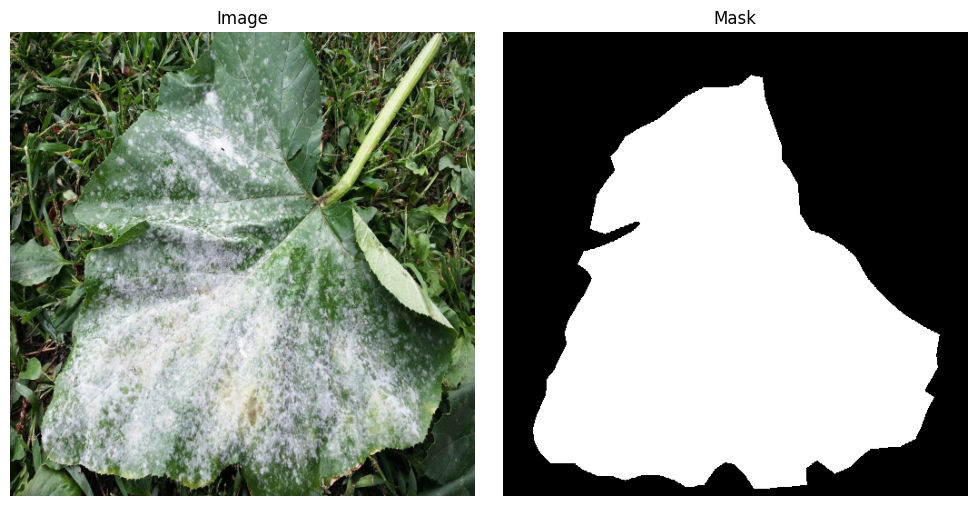

---------------Validation---------------


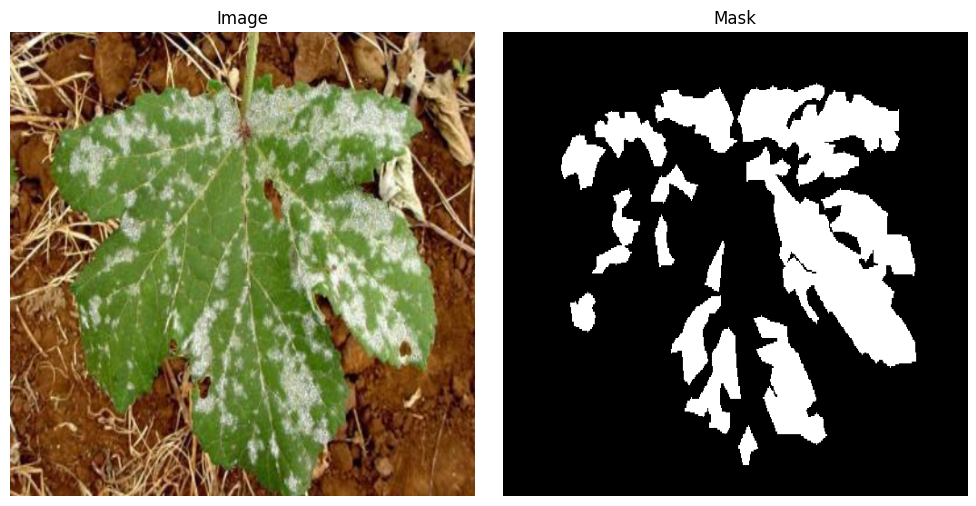

In [ ]:
print("---------------Train---------------")
show_single_img(index=15,train=True)
print("---------------Validation---------------")
show_single_img(index=15,train=False)

### **6.2 DataLoader Configuration**

The PyTorch DataLoader provides an efficient way to:

1. **Batch Processing**: Group samples for parallel processing
2. **Shuffling**: Randomize data order to prevent learning sequence-dependent patterns
3. **Memory Management**: Control memory usage through batch size settings
4. **Multiprocessing**: Utilize multiple CPU cores for data loading operations

This section configures DataLoaders for both training and validation datasets with appropriate parameters.

In [ ]:
train_dataloader = DataLoader(train_dataset,batch_size=CFG.batch_size,shuffle=True)
val_dataloader = DataLoader(val_dataset,batch_size=CFG.batch_size,shuffle=False)

In [ ]:
try:
    a = iter(train_dataloader)
    img, mask = next(a)
    print(img.shape, mask.shape)
except Exception as e:
    print(f"An error occurred: {e}")


torch.Size([4, 3, 512, 512]) torch.Size([4, 1, 512, 512])


## **7. U-Net Architecture Implementation**

### **7.1 Building Blocks and Helper Functions**

The U-Net architecture consists of specialized building blocks that must be carefully implemented:

#### **Double Convolution Block**
This fundamental block appears throughout the U-Net architecture and consists of:
- Two sequential 3×3 convolutional layers
- Batch normalization after each convolution for training stability
- ReLU activation functions for non-linearity

#### **Padding Function**
When concatenating feature maps from the encoder with those in the decoder:
- Feature map dimensions may not match exactly due to operations like pooling and convolutions
- A padding function ensures proper alignment of features during skip connections

The implementation below establishes these critical components for the full U-Net architecture.

In [ ]:
def double_conv(in_ch, out_ch):
    """
    Double convolution block used throughout U-Net architecture

    Args:
        in_ch (int): Number of input channels
        out_ch (int): Number of output channels

    Returns:
        nn.Sequential: Sequential container of layers in the double conv block
    """
    conv = nn.Sequential(
        # First convolution layer
        nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(out_ch),  # Batch normalization for training stability
        nn.ReLU(inplace=True),   # ReLU activation

        # Second convolution layer
        nn.Conv2d(in_channels=out_ch, out_channels=out_ch, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(out_ch),  # Batch normalization
        nn.ReLU(inplace=True)    # ReLU activation
    )
    return conv


def padder(left_tensor, right_tensor):
    """
    Padding function to ensure dimension compatibility during skip connections

    Args:
        left_tensor (torch.Tensor): Tensor from encoder path (larger)
        right_tensor (torch.Tensor): Tensor from decoder path (smaller)

    Returns:
        torch.Tensor: Padded tensor with dimensions matching left_tensor
    """
    if left_tensor.shape != right_tensor.shape:
        # Create a zero tensor with same shape as left_tensor
        padded = torch.zeros(left_tensor.shape)
        # Copy right_tensor values into the padded tensor
        padded[:, :, :right_tensor.shape[2], :right_tensor.shape[3]] = right_tensor
        return padded.to(CFG.device)

    # If dimensions already match, no padding needed
    return right_tensor.to(CFG.device)

### **7.2 U-Net Model Architecture**

The U-Net architecture consists of two main paths:

#### **Contracting Path (Encoder)**
- Progressively reduces spatial dimensions while increasing feature channels
- Captures contextual information and high-level features
- Consists of repeated double convolution blocks followed by max pooling

#### **Expansive Path (Decoder)**
- Progressively increases spatial dimensions while decreasing feature channels
- Restores spatial information for precise localization
- Consists of transposed convolutions followed by double convolution blocks

#### **Skip Connections**
- Connect corresponding layers between encoder and decoder
- Allow flow of spatial information lost during downsampling
- Implemented by concatenating feature maps along the channel dimension

The implementation below follows the original U-Net paper with minor modifications for stability and performance.

In [ ]:
class UNET(nn.Module):
    """
    U-Net architecture for image segmentation as described in:
    "U-Net: Convolutional Networks for Biomedical Image Segmentation"

    The architecture follows an encoder-decoder pattern with skip connections
    between corresponding layers of the encoder and decoder.
    """
    def __init__(self, in_chnls, n_classes):
        """
        Initialize the U-Net architecture.

        Args:
            in_chnls (int): Number of input channels (3 for RGB images)
            n_classes (int): Number of output classes (1 for binary segmentation)
        """
        super(UNET, self).__init__()

        self.in_chnls = in_chnls
        self.n_classes = n_classes

        # Max pooling operation used in the encoder path
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder (Contracting) Path - Double convolution blocks
        self.down_conv_1 = double_conv(in_ch=self.in_chnls, out_ch=64)
        self.down_conv_2 = double_conv(in_ch=64, out_ch=128)
        self.down_conv_3 = double_conv(in_ch=128, out_ch=256)
        self.down_conv_4 = double_conv(in_ch=256, out_ch=512)
        self.down_conv_5 = double_conv(in_ch=512, out_ch=1024)

        # Decoder (Expansive) Path - Transposed convolutions for upsampling
        self.up_conv_trans_1 = nn.ConvTranspose2d(in_channels=1024, out_channels=512, kernel_size=2, stride=2)
        self.up_conv_trans_2 = nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=2, stride=2)
        self.up_conv_trans_3 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=2, stride=2)
        self.up_conv_trans_4 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2)

        # Decoder Path - Double convolution blocks after concatenation with skip connections
        self.up_conv_1 = double_conv(in_ch=1024, out_ch=512)  # 512 + 512 = 1024 channels after concat
        self.up_conv_2 = double_conv(in_ch=512, out_ch=256)   # 256 + 256 = 512 channels after concat
        self.up_conv_3 = double_conv(in_ch=256, out_ch=128)   # 128 + 128 = 256 channels after concat
        self.up_conv_4 = double_conv(in_ch=128, out_ch=64)    # 64 + 64 = 128 channels after concat

        # Final 1x1 convolution to produce the segmentation map
        self.conv_1x1 = nn.Conv2d(in_channels=64, out_channels=self.n_classes, kernel_size=1, stride=1)

    def forward(self, x):
        """
        Forward pass through the U-Net architecture.

        Args:
            x (torch.Tensor): Input tensor of shape [batch_size, in_channels, height, width]

        Returns:
            torch.Tensor: Output segmentation map
        """
        # Encoding path (contracting)
        x1 = self.down_conv_1(x)       # First encoder block output
        p1 = self.max_pool(x1)         # First max pooling output

        x2 = self.down_conv_2(p1)      # Second encoder block output
        p2 = self.max_pool(x2)         # Second max pooling output

        x3 = self.down_conv_3(p2)      # Third encoder block output
        p3 = self.max_pool(x3)         # Third max pooling output

        x4 = self.down_conv_4(p3)      # Fourth encoder block output
        p4 = self.max_pool(x4)         # Fourth max pooling output

        x5 = self.down_conv_5(p4)      # Bottom of the U (bridge)

        # Decoding path (expanding) with skip connections
        # First decoder stage
        d1 = self.up_conv_trans_1(x5)                  # Upsample
        pad1 = padder(x4, d1)                          # Pad to match dimensions if needed
        cat1 = torch.cat([x4, pad1], dim=1)            # Concatenate with skip connection
        uc1 = self.up_conv_1(cat1)                     # Apply convolutions

        # Second decoder stage
        d2 = self.up_conv_trans_2(uc1)                 # Upsample
        pad2 = padder(x3, d2)                          # Pad to match dimensions if needed
        cat2 = torch.cat([x3, pad2], dim=1)            # Concatenate with skip connection
        uc2 = self.up_conv_2(cat2)                     # Apply convolutions

        # Third decoder stage
        d3 = self.up_conv_trans_3(uc2)                 # Upsample
        pad3 = padder(x2, d3)                          # Pad to match dimensions if needed
        cat3 = torch.cat([x2, pad3], dim=1)            # Concatenate with skip connection
        uc3 = self.up_conv_3(cat3)                     # Apply convolutions

        # Fourth decoder stage
        d4 = self.up_conv_trans_4(uc3)                 # Upsample
        pad4 = padder(x1, d4)                          # Pad to match dimensions if needed
        cat4 = torch.cat([x1, pad4], dim=1)            # Concatenate with skip connection
        uc4 = self.up_conv_4(cat4)                     # Apply convolutions

        # Final 1x1 convolution to produce segmentation map
        output = self.conv_1x1(uc4)
        return output

## **8. Model Training and Evaluation Framework**

### **8.1 Performance Metrics**

Evaluating image segmentation models requires specialized metrics that assess the spatial overlap between predictions and ground truth:

- **Dice Coefficient (F1 Score)**: Measures the overlap between predicted and ground truth segmentation masks
  - Formula: 2|X∩Y|/(|X|+|Y|), where X is the prediction and Y is the ground truth
  - Range: [0,1], where 1 indicates perfect overlap
  - Advantages: Accounts for both precision and recall, less sensitive to class imbalance

The implementation below defines the Dice score calculation for binary segmentation tasks.

### **8.2 Training Process**

The training function implements a complete training loop for each epoch:

1. **Forward Pass**: Computing model predictions for input images
2. **Loss Calculation**: Evaluating the binary cross-entropy loss between predictions and ground truth
3. **Backpropagation**: Computing gradients with respect to model parameters
4. **Parameter Updates**: Adjusting model parameters using the optimizer
5. **Metric Tracking**: Monitoring performance with the Dice coefficient

This structured approach ensures systematic model training with appropriate progress tracking.

In [ ]:
def dice_score(preds, labels, eps=1e-7):
    """
    Calculate the Dice coefficient (F1 score) between predicted and ground truth segmentation masks.

    The Dice coefficient is defined as:
    Dice = (2 * |X ∩ Y|) / (|X| + |Y|)
    where X is the predicted set and Y is the ground truth set.

    Args:
        preds (torch.Tensor): Predicted segmentation logits
        labels (torch.Tensor): Ground truth segmentation masks
        eps (float): Small epsilon value to avoid division by zero

    Returns:
        torch.Tensor: Dice coefficient value between 0 and 1
    """
    # Apply sigmoid to convert logits to probabilities
    preds = preds.sigmoid()

    # Threshold predictions to get binary masks
    preds = (preds > 0.5).float()

    # Calculate intersection between prediction and ground truth
    intersection = (preds * labels).sum()

    # Calculate union (sum of prediction and ground truth elements)
    union = preds.sum() + labels.sum() + eps

    # Calculate Dice coefficient
    dice = (2. * intersection + eps) / union

    return dice

In [ ]:
def train_model(model, dataloader, criterion, optimizer):
    """
    Train the segmentation model for one epoch

    Args:
        model (nn.Module): The U-Net model to train
        dataloader (DataLoader): DataLoader providing training batches
        criterion (nn.Module): Loss function (typically BCEWithLogitsLoss for binary segmentation)
        optimizer (torch.optim.Optimizer): Optimization algorithm

    Returns:
        tuple: (average_loss, average_dice_score) for the epoch
    """
    # Set model to training mode
    model.train()

    # Initialize metrics
    train_running_loss = 0.0
    train_running_dice_score = 0.0

    # Iterate through batches with progress tracking
    for j, img_mask in enumerate(tqdm(dataloader)):
        # Move inputs and targets to device
        img = img_mask[0].float().to(CFG.device)
        mask = img_mask[1].float().to(CFG.device)

        # Forward pass: compute predictions
        y_pred = model(img)

        # Compute loss
        loss = criterion(y_pred, mask)

        # Accumulate batch loss
        train_running_loss += loss.item() * CFG.batch_size

        # Calculate and accumulate Dice score
        dice = dice_score(y_pred, mask)
        train_running_dice_score += dice.item()

        # Backpropagation and optimization
        optimizer.zero_grad()       # Clear previous gradients
        loss.backward()             # Compute gradients
        optimizer.step()            # Update model parameters

    # Calculate average metrics for the epoch
    train_loss = train_running_loss / (j + 1)
    train_dice_score = train_running_dice_score / (j + 1)

    return train_loss, train_dice_score

### **8.3 Validation Process**

Validation is crucial for monitoring model generalization and preventing overfitting:

1. **No Parameter Updates**: Unlike training, validation only assesses model performance without updating parameters
2. **Gradient Deactivation**: Using `torch.no_grad()` to disable gradient computation for efficiency
3. **Performance Assessment**: Calculating the same metrics as in training for direct comparison
4. **Memory Efficiency**: Processing batches individually to manage memory consumption

The function below implements the validation process with appropriate memory management and metric calculation.

In [ ]:
def val_model(model, dataloader, criterion):
    """
    Evaluate the segmentation model on validation data

    Args:
        model (nn.Module): The U-Net model to evaluate
        dataloader (DataLoader): DataLoader providing validation batches
        criterion (nn.Module): Loss function (typically BCEWithLogitsLoss for binary segmentation)

    Returns:
        tuple: (average_loss, average_dice_score) for the validation set
    """
    # Set model to evaluation mode (disables dropout, etc.)
    model.eval()

    # Initialize metrics
    val_running_loss = 0.0
    val_running_dice_score = 0.0

    # Disable gradient computation for efficiency
    with torch.no_grad():
        # Iterate through validation batches with progress tracking
        for j, img_mask in enumerate(tqdm(dataloader)):
            # Move inputs and targets to device
            img = img_mask[0].float().to(CFG.device)
            mask = img_mask[1].float().to(CFG.device)

            # Forward pass: compute predictions
            y_pred = model(img)

            # Compute loss
            loss = criterion(y_pred, mask)

            # Accumulate batch loss
            val_running_loss += loss.item() * CFG.batch_size

            # Calculate and accumulate Dice score
            dice = dice_score(y_pred, mask)
            val_running_dice_score += dice.item()

        # Calculate average metrics for the validation set
        val_loss = val_running_loss / (j + 1)
        val_dice_score = val_running_dice_score / (j + 1)

    return val_loss, val_dice_score

## **9. Model Training and Evaluation**

### **9.1 Model Initialization and Training Loop**

This section implements the complete training pipeline:

1. **Model Initialization**: Creating and configuring the U-Net architecture
2. **Optimizer Configuration**: Setting up the Adam optimizer with an appropriate learning rate
3. **Loss Function Selection**: Using Binary Cross-Entropy with Logits Loss for binary segmentation
4. **Training Loop**: Executing training and validation for multiple epochs
5. **Progress Tracking**: Monitoring performance metrics across epochs

The training procedure follows best practices for deep learning model development with systematic evaluation.

In [ ]:
model = UNET(in_chnls = 3, n_classes = 1).to(CFG.device)
optimizer = optim.Adam(model.parameters(), lr = CFG.learning_rate)
criterion = nn.BCEWithLogitsLoss()
train_loss_lst = []
val_loss_lst = []
train_dice_lst = []
val_dice_lst = []
for i in tqdm(range(CFG.epochs)):
    train_loss, train_dice = train_model(model=model, dataloader=train_dataloader, criterion=criterion, optimizer=optimizer)
    val_loss, val_dice = val_model(model=model, dataloader=val_dataloader, criterion=criterion)

    train_loss_lst.append(train_loss)
    val_loss_lst.append(val_loss)
    train_dice_lst.append(train_dice)
    val_dice_lst.append(val_dice)

    print(f"Epoch {i+1}/{CFG.epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f}")
    print(f"Validation Loss: {val_loss:.4f} | Validation Dice: {val_dice:.4f}")


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/118 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/3
Train Loss: 1.4592 | Train Dice: 0.2987
Validation Loss: 1.7567 | Validation Dice: 0.1897


  0%|          | 0/118 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 2/3
Train Loss: 1.3471 | Train Dice: 0.2627
Validation Loss: 1.6045 | Validation Dice: 0.2023


  0%|          | 0/118 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 3/3
Train Loss: 1.3656 | Train Dice: 0.3525
Validation Loss: 1.5315 | Validation Dice: 0.2502


### **9.2 Performance Visualization and Analysis**

Visualizing model performance across epochs provides valuable insights:

1. **Convergence Assessment**: Determine if the model is converging to an optimal solution
2. **Overfitting Detection**: Compare training and validation loss trends to identify potential overfitting
3. **Learning Rate Adequacy**: Evaluate if the learning rate is appropriate based on loss dynamics
4. **Performance Plateaus**: Identify when model performance stabilizes, suggesting potential early stopping points

The plot below visualizes the training and validation loss trajectories throughout the training process.

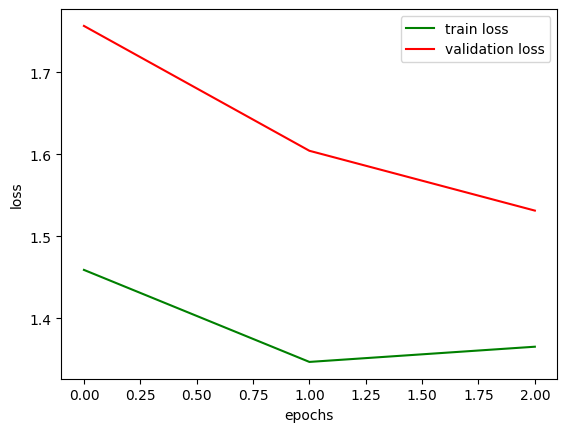

In [ ]:
plt.plot(train_loss_lst, color="green", label='train loss')
plt.plot(val_loss_lst, color="red", label='validation loss')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

## **10. Model Persistence and Deployment**

### **10.1 Model Serialization**

Model persistence is essential for practical deployment and future use:

1. **Parameter Preservation**: Save trained model parameters without requiring retraining
2. **Deployment Preparation**: Enable model use in production environments
3. **Experiment Reproducibility**: Allow exact reproduction of model results
4. **Transfer Learning**: Enable fine-tuning for related tasks

PyTorch provides a straightforward mechanism to save and load model parameters using `torch.save()` and `torch.load()` functions.

In [ ]:
TRAINED_FILE = "./unet_scratch_new.pth"

In [ ]:
torch.save(model.state_dict(), TRAINED_FILE)

In [ ]:
from IPython.display import FileLink
FileLink(TRAINED_FILE)

/content/unet_scratch_new.pth

## **11. Inference and Qualitative Evaluation**

### **11.1 Model Loading and Inference Setup**

The final stage of the machine learning workflow involves applying the trained model to new data:

1. **Model Restoration**: Loading the saved model parameters into a newly initialized architecture
2. **Inference Mode**: Setting the model to evaluation mode to disable training-specific behaviors
3. **Device Management**: Ensuring computation occurs on the appropriate hardware (CPU or GPU)
4. **Input Processing**: Preparing new data with the same preprocessing steps as during training

This section demonstrates how to load a saved model and prepare it for inference on new images.

In [ ]:
trained_model = UNET(in_chnls = 3, n_classes = 1)

Pretrained Weights

In [ ]:
!gdown https://drive.google.com/uc?id=13-2sYVkR9FodpMD7SRIEr9K2SKtSuKqi

Downloading...
From (original): https://drive.google.com/uc?id=13-2sYVkR9FodpMD7SRIEr9K2SKtSuKqi
From (redirected): https://drive.google.com/uc?id=13-2sYVkR9FodpMD7SRIEr9K2SKtSuKqi&confirm=t&uuid=87d6a9a0-37df-45af-b434-a8836ccd7980
To: /content/unet_scratch.pth
100% 124M/124M [00:03<00:00, 38.8MB/s]


In [ ]:
UNET_TRAINED = "/content/unet_scratch.pth"

In [ ]:
trained_model.load_state_dict(torch.load(UNET_TRAINED))

<All keys matched successfully>

In [ ]:
trained_model = trained_model.to("cuda")
trained_model.eval()


UNET(
  (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down_conv_1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (down_conv_2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (down_conv_3): Sequential(
    (0): Conv2d(128, 256, kernel_size=

In [ ]:
img_path = os.path.join(ROOTDIR.train, val_images_list[0])
img = cv2.imread(img_path)
img.shape

(235, 326, 3)

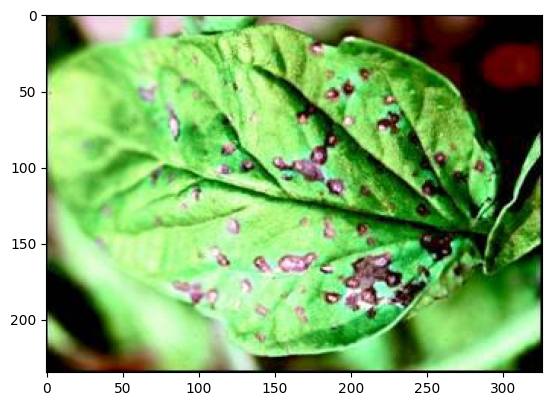

In [ ]:
plt.imshow(img)
plt.show()

In [ ]:
test_transform = A.Compose([A.Resize(512,512),
                           A.Normalize(mean=(0,0,0),std=(1,1,1),max_pixel_value=255),
                           ToTensorV2()])

In [ ]:
test_image = test_transform(image = img)

print(test_image["image"].dtype)
print(test_image["image"].shape)

img = test_image["image"].unsqueeze(0)
print(img.shape)

img = img.to("cuda")

torch.float32
torch.Size([3, 512, 512])
torch.Size([1, 3, 512, 512])


In [ ]:
pred = trained_model(img)
pred.shape

torch.Size([1, 1, 512, 512])

In [ ]:
mask = pred.squeeze(0).cpu().detach().numpy()
print(mask.shape)
mask = mask.transpose(1,2,0)
print(mask.shape)

(1, 512, 512)
(512, 512, 1)


In [ ]:
display_test_img = test_image["image"].cpu().detach().numpy()
print(display_test_img.shape)
display_test_img = display_test_img.transpose(1,2,0)
display_test_img.shape

(3, 512, 512)


(512, 512, 3)

In [ ]:
mask[mask < 0]=0
mask[mask > 0]=1

-------Original Image-------


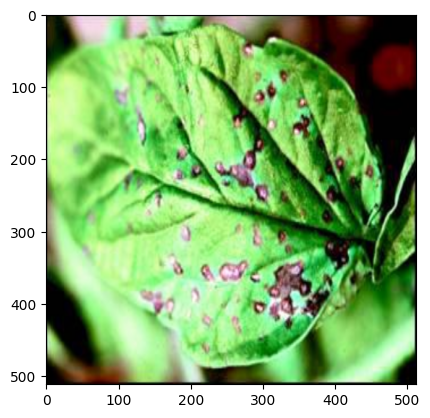

-------Image Mask-------


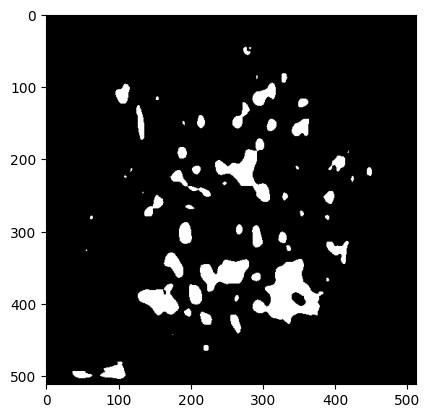

In [ ]:
print("-------Original Image-------")
plt.imshow(display_test_img, cmap="gray")
plt.show()
print("-------Image Mask-------")
plt.imshow(mask,cmap="gray")
plt.show()

In [ ]:
# Load the ground truth mask for the first validation image
ground_truth_mask_path = os.path.join(ROOTDIR.train_mask, val_masks_list[0])
ground_truth_mask = Image.open(ground_truth_mask_path).convert("L")
ground_truth_mask_np = np.array(ground_truth_mask)

# Binarize the ground truth mask
ground_truth_mask_np[ground_truth_mask_np != 0] = 1

# Resize the ground truth mask to match the predicted mask dimensions
ground_truth_mask_resized = cv2.resize(ground_truth_mask_np, (512, 512), interpolation=cv2.INTER_NEAREST)

# Convert to tensor and add batch and channel dimensions
ground_truth_mask_tensor = torch.from_numpy(ground_truth_mask_resized).unsqueeze(0).unsqueeze(0).float().to(CFG.device)

# Ensure the predicted mask is also a tensor and on the correct device
predicted_mask_tensor = torch.from_numpy(mask).permute(2, 0, 1).unsqueeze(0).float().to(CFG.device)


# Calculate the Dice score
dice = dice_score(predicted_mask_tensor, ground_truth_mask_tensor)

print(f"Dice score for the predicted mask: {dice.item():.4f}")

Dice score for the predicted mask: 0.7050


## **12. Conclusion

This tutorial has demonstrated a complete implementation of the U-Net architecture:

1. **Architecture Implementation**: We built the U-Net model from scratch following the original paper's design principles
2. **Data Processing**: We established a robust data processing pipeline with appropriate augmentation and preprocessing
3. **Training Methodology**: We implemented a systematic training approach with performance tracking
4. **Evaluation**: We assessed model performance using the Dice coefficient, a standard metric for segmentation tasks
5. **Inference**: We demonstrated how to apply the trained model to new images